In [2]:
from __future__ import annotations

In [3]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>'))

In [4]:
import os
import datetime
import numpy as np
import sklearn.metrics
import tensorflow as tf
import sklearn.datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('dark')
sns.set(rc={'figure.figsize': (10, 10), 'axes.grid': False})

In [6]:
rng = np.random.default_rng()

In [7]:
def plot_grid(X, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    imgs = X[rng.choice(np.arange(X.shape[0]), size=ax.shape)].reshape(*ax.shape, 28, 28)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [8]:
def plot_grid_and_label(X, y, model, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, flatten_image=True, label_description=None):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]
    inputs = imgs.reshape(-1, *imgs.shape[2:])
    
    if flatten_image:
        inputs = inputs.reshape(nrows * ncols, -1)
        
    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])
        
    preds = np.argmax(tf.nn.softmax(model.predict(inputs)), axis=-1).reshape(nrows, ncols)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            ax[i, j].set_title(f'label: {map_label(labels[i, j])}, prediction: {map_label(preds[i, j])}')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [9]:
label_description = [
     'A',   'I',   'U',  'E',  'O',
    'KA',  'KI',  'KU', 'KE', 'KO',
    'SA', 'SHI',  'SU', 'SE', 'SO',
    'TA', 'CHI', 'TSU', 'TE', 'TO',
    'NA',  'NI',  'NU', 'NE', 'NO',
    'HA',  'HI',  'FU', 'HE', 'HO',
    'MA',  'MI',  'MU', 'ME', 'MO',
    'YA',         'YU',       'YO',
    'RA',  'RI',  'RU', 'RE', 'RO',
    'WA',  'II',        'EE', 'WO',
     'N',  'IT'
]

In [10]:
X, y = sklearn.datasets.fetch_openml('Kuzushiji-49', version=1, return_X_y=True, as_frame=False, parser='auto')
y = np.array(list(map(int, y)))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [11]:
counts = { j: np.sum(y_train == i) for i, j in enumerate(label_description) }

In [12]:
counts # what to do with imbalanced classes?

{'A': np.int64(5258),
 'I': np.int64(5241),
 'U': np.int64(5293),
 'E': np.int64(704),
 'O': np.int64(5266),
 'KA': np.int64(5265),
 'KI': np.int64(5275),
 'KU': np.int64(5278),
 'KE': np.int64(4128),
 'KO': np.int64(5284),
 'SA': np.int64(5194),
 'SHI': np.int64(5262),
 'SU': np.int64(5223),
 'SE': np.int64(3634),
 'SO': np.int64(3387),
 'TA': np.int64(5247),
 'CHI': np.int64(2239),
 'TSU': np.int64(5224),
 'TE': np.int64(5237),
 'TO': np.int64(5247),
 'NA': np.int64(5215),
 'NI': np.int64(5287),
 'NU': np.int64(1805),
 'NE': np.int64(2128),
 'NO': np.int64(5188),
 'HA': np.int64(5261),
 'HI': np.int64(4398),
 'FU': np.int64(5315),
 'HE': np.int64(5257),
 'HO': np.int64(1786),
 'MA': np.int64(5208),
 'MI': np.int64(2719),
 'MU': np.int64(1470),
 'ME': np.int64(3000),
 'MO': np.int64(5233),
 'YA': np.int64(5226),
 'YU': np.int64(1375),
 'YO': np.int64(5235),
 'RA': np.int64(5254),
 'RI': np.int64(5284),
 'RU': np.int64(5236),
 'RE': np.int64(5299),
 'RO': np.int64(1847),
 'WA': np.int6

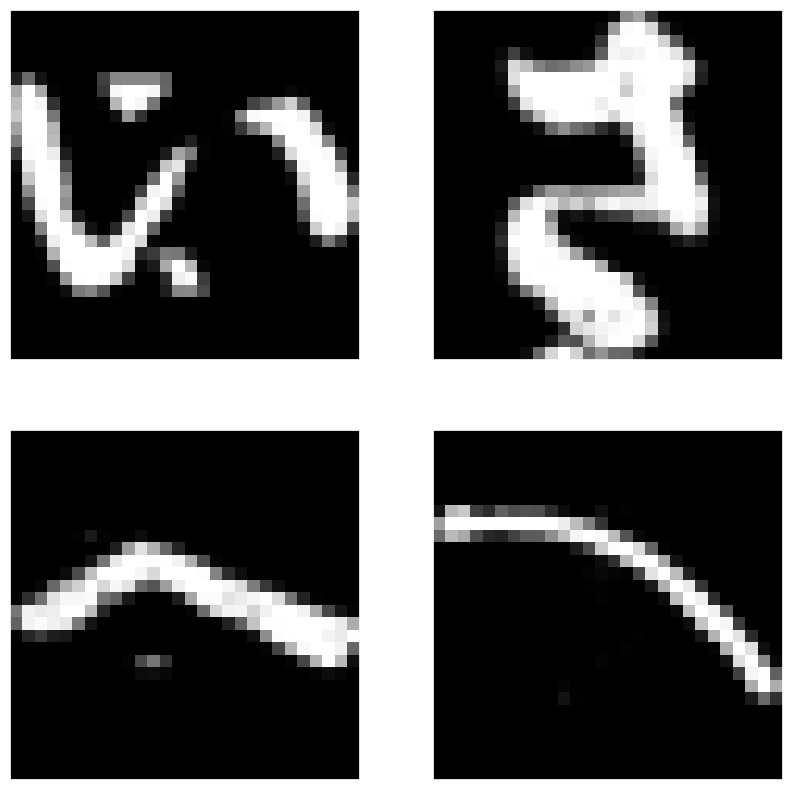

In [13]:
plot_grid(X_train)

## Flattened images
Use Dense layers

Плоское

In [13]:
# create train and validation datasets, these datasets should use flattened images
# Нормализуем значения пикселей и превращаем 28x28 в 784 (flattened)
X_train_flat = X_train / 255.0
X_test_flat = X_test / 255.0

# Дополнительно разобьём X_train_flat на обучающую и валидационную части
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_flat, y_train, test_size=0.2, random_state=42)

In [14]:
# create model, this model should accept a flattened image
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Input(shape=(784,)),                   
    layers.Dense(512, activation='relu'),       
    layers.Dropout(0.3),                          
    layers.Dense(256, activation='relu'),         
    layers.Dropout(0.3),
    layers.Dense(49, activation='softmax') 
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 49)                  │          12,593 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 545,841 (2.08 MB)

 Trainable params: 545,841 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

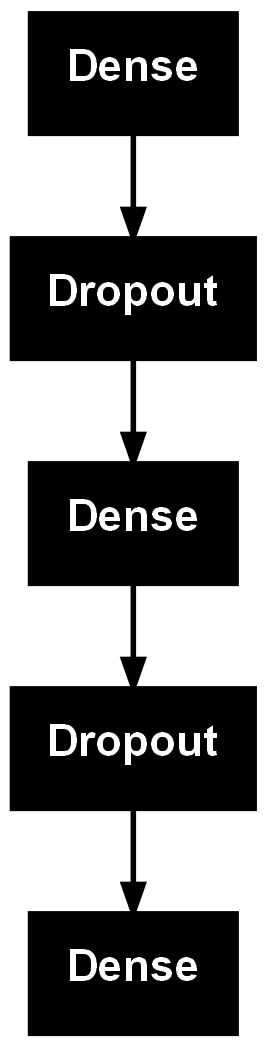

In [16]:
tf.keras.utils.plot_model(model)

In [17]:
logdir = os.path.join('logs/kuzushiji-49/', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

In [18]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(logdir, 'best_model.keras'), save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [19]:
# compile the model, make sure to add accuracy metric
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # так как y — целочисленные метки классов
    metrics=['accuracy']
)


In [27]:
# train the model, make sure to use callbacks and validation dataset
history = model.fit(
    X_train_final, y_train_final,
    epochs=40,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)


Epoch 1/40
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9160 - loss: 0.2847 - val_accuracy: 0.9157 - val_loss: 0.3560
Epoch 2/40
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9169 - loss: 0.2784 - val_accuracy: 0.9132 - val_loss: 0.3685
Epoch 3/40
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9169 - loss: 0.2867 - val_accuracy: 0.9135 - val_loss: 0.3618
Epoch 4/40
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9185 - loss: 0.2768 - val_accuracy: 0.9147 - val_loss: 0.3564
Epoch 5/40
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9183 - loss: 0.2787 - val_accuracy: 0.9150 - val_loss: 0.3570
Epoch 6/40
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9198 - loss: 0.2774 - val_accuracy: 0.9141 - val_loss: 0.3684
Epoch 7/40
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9198 - loss: 0.2709 - val_accuracy: 0.9146 - val_loss: 0.3628
Epoch 8/40
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9191 - loss: 0

In [28]:
# images = X_test.reshape(-1, 28, 28, 1) # normalize if needed
X_test = np.array(X_test)
images = X_test.astype("float32") / 255.0
images = images.reshape(-1, 28, 28, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


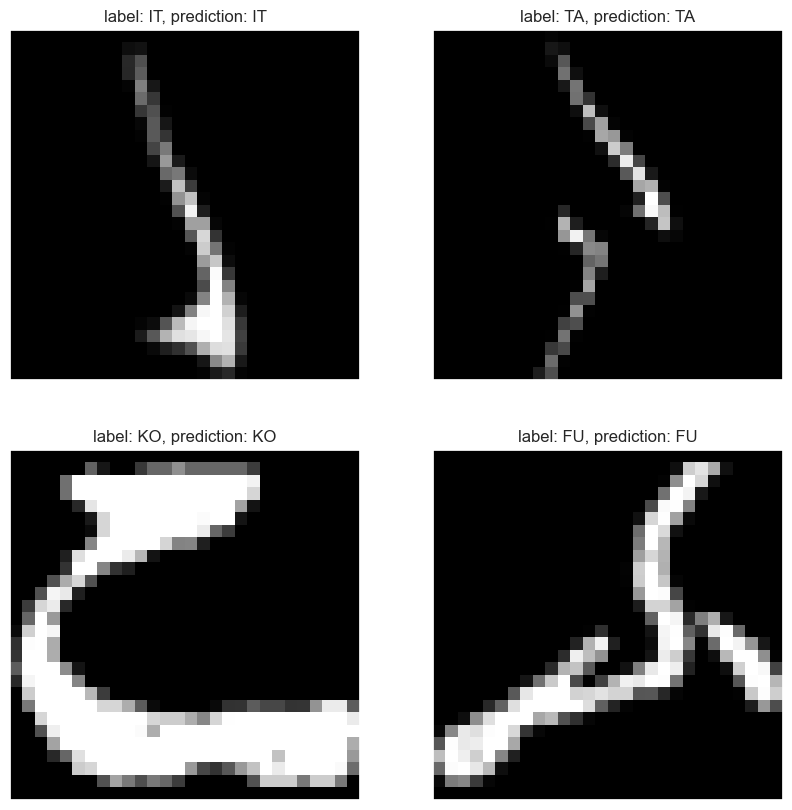

In [29]:
plot_grid_and_label(images, y_test, model, label_description=label_description)

In [30]:
import numpy as np

print("Тип images:", type(images))
print("Форма images:", getattr(images, "shape", "нет shape"))

if len(images.shape) == 2:
    images = np.expand_dims(images, axis=0)

if len(images.shape) == 3 and images.shape[-1] not in [1, 3]:
    images = np.expand_dims(images, axis=-1)

print("Форма после обработки:", images.shape)


Тип images: <class 'numpy.ndarray'>
Форма images: (67728, 28, 28, 1)
Форма после обработки: (67728, 28, 28, 1)


In [31]:
images_flat = images.reshape((images.shape[0], -1))  # (67728, 784)

y_pred = np.argmax(model.predict(images_flat), axis=1)

2117/2117 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


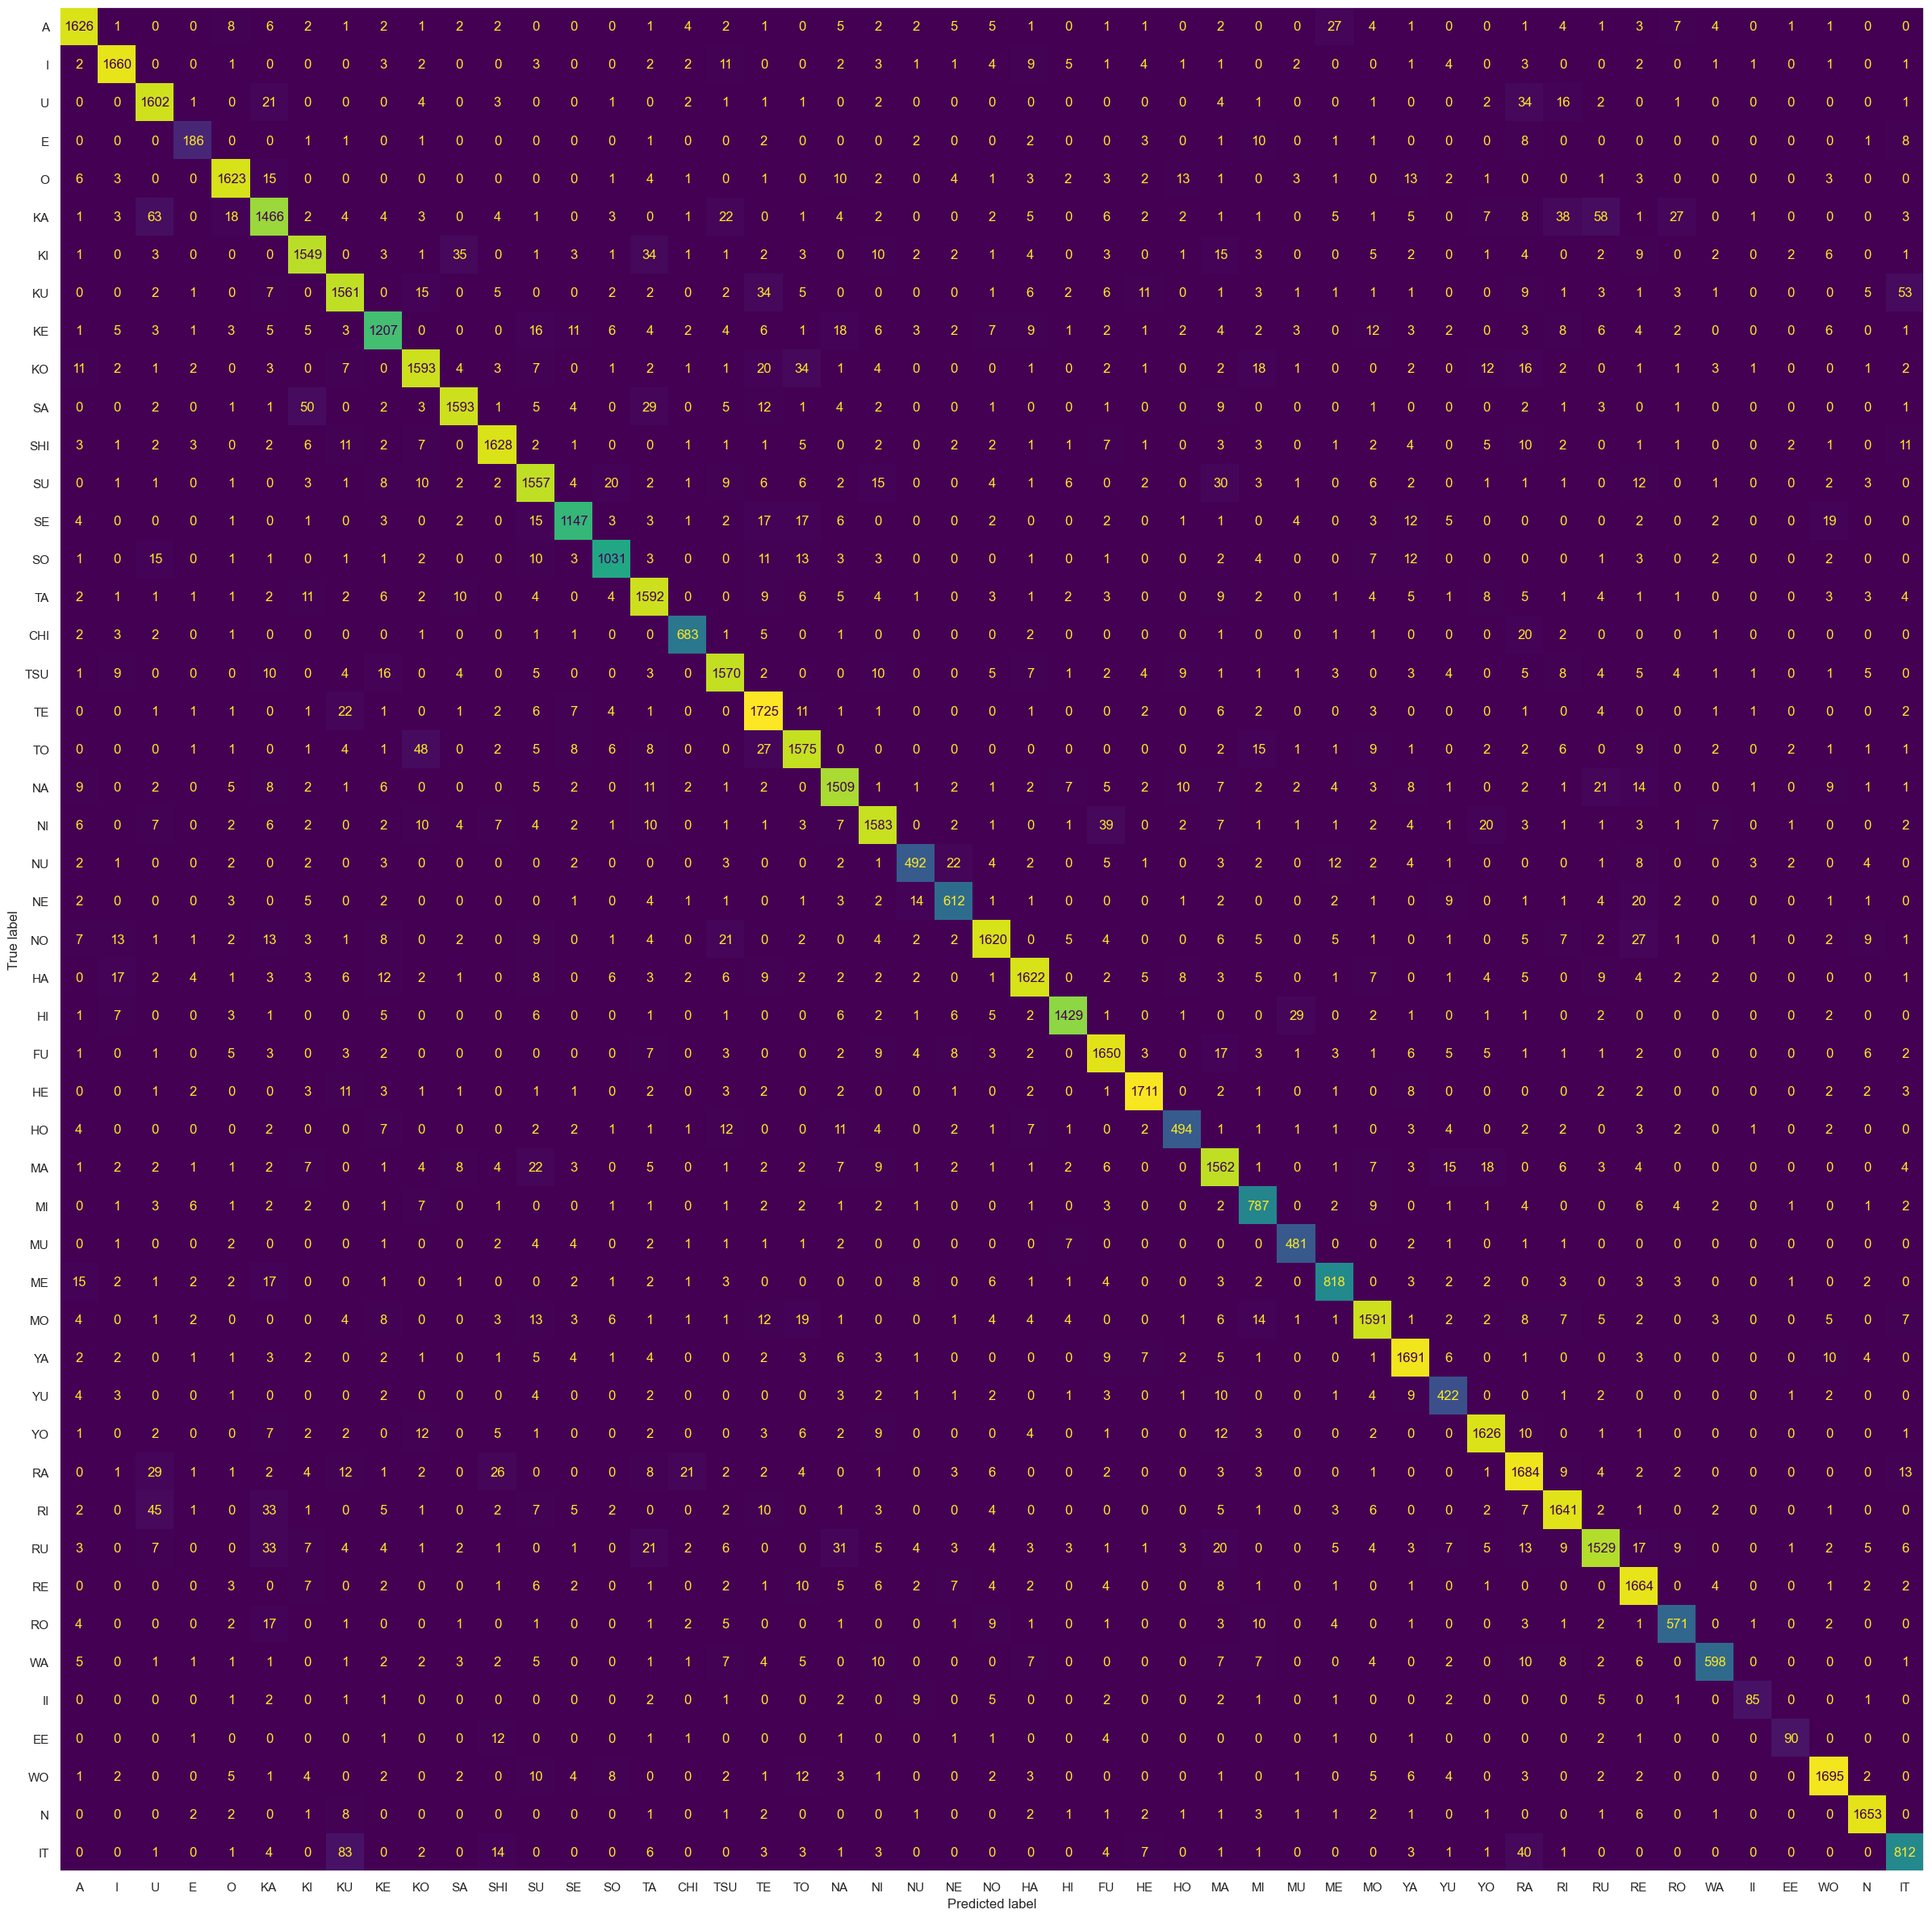

In [32]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [33]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.9002847903804279)

## Actual images
Use Conv2D layers with Dense layer on top

Обычное

In [14]:
X = X.astype("float32") / 255.0  # нормализация
X = X.reshape(-1, 28, 28, 1)

In [15]:
# create train and validation datasets, these datasets should use 28x28x1 images
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

y_train_cat = tf.keras.utils.to_categorical(y_train, 49)
y_val_cat = tf.keras.utils.to_categorical(y_val, 49)

In [18]:
# create model, this model should accept a 28x28x1 image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import Input

model_2 = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(49, activation='softmax')
])


In [19]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 49)                  │           6,321 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 427,057 (1.63 MB)

 Trainable params: 426,865 (1.63 MB)

 Non-trainable params: 192 (768.00 B)

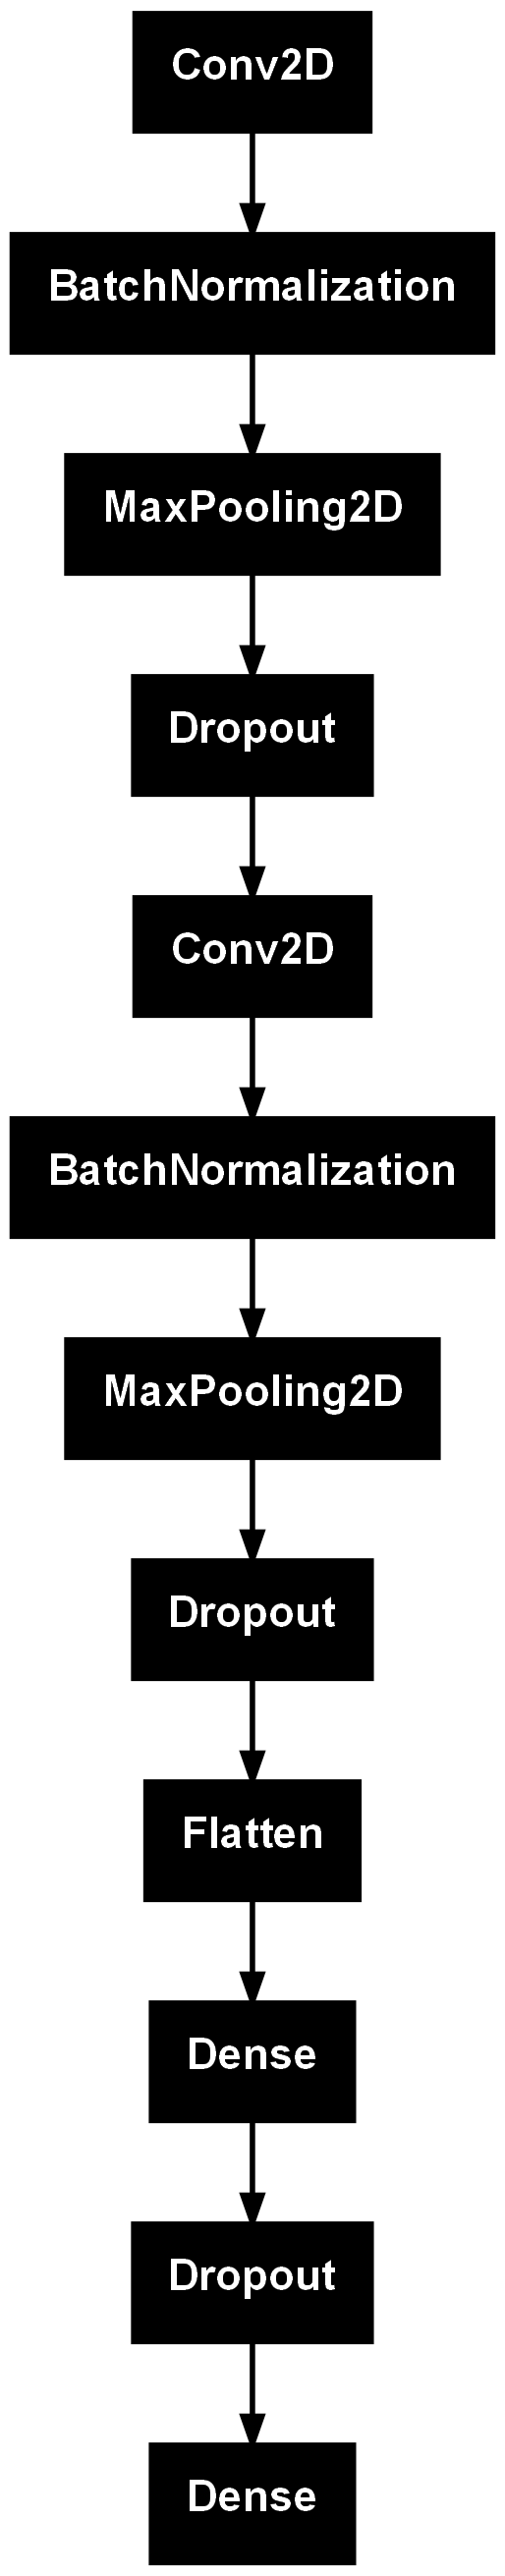

In [20]:
tf.keras.utils.plot_model(model_2)

In [21]:
logdir = os.path.join('logs/kuzushiji-49/', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

In [25]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(logdir, 'best_model_2.keras'), save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.TensorBoard(logdir, update_freq=10),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1)
]

In [26]:
# compile the model, make sure to add accuracy metric
model_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [27]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

In [28]:
# train the model, make sure to use callbacks and validation dataset
history = model_2.fit(
    X_train, y_train_cat,
    epochs=40,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks
)

Epoch 1/40
2964/2964 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - accuracy: 0.4873 - loss: 1.9967 - val_accuracy: 0.8855 - val_loss: 0.4239 - learning_rate: 0.0010
Epoch 2/40
2964/2964 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.7837 - loss: 0.7763 - val_accuracy: 0.9241 - val_loss: 0.2857 - learning_rate: 0.0010
Epoch 3/40
2964/2964 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - accuracy: 0.8356 - loss: 0.5895 - val_accuracy: 0.9365 - val_loss: 0.2414 - learning_rate: 0.0010
Epoch 4/40
2964/2964 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - accuracy: 0.8575 - loss: 0.5054 - val_accuracy: 0.9416 - val_loss: 0.2185 - learning_rate: 0.0010
Epoch 5/40
2964/2964 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.8736 - loss: 0.4455 - val_accuracy: 0.9443 - val_loss: 0.2124 - learning_rate: 0.0010
Epoch 6/40
2964/2964 ━━━━━━━━━━━━━━━━━━━━ 52s 18ms/step - accuracy: 0.8842 - loss: 0.4044 - val_accuracy: 0.9529 - val_loss: 0.1818 - learning_rate: 0.0010
Epoch 7/40
2964/2964 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


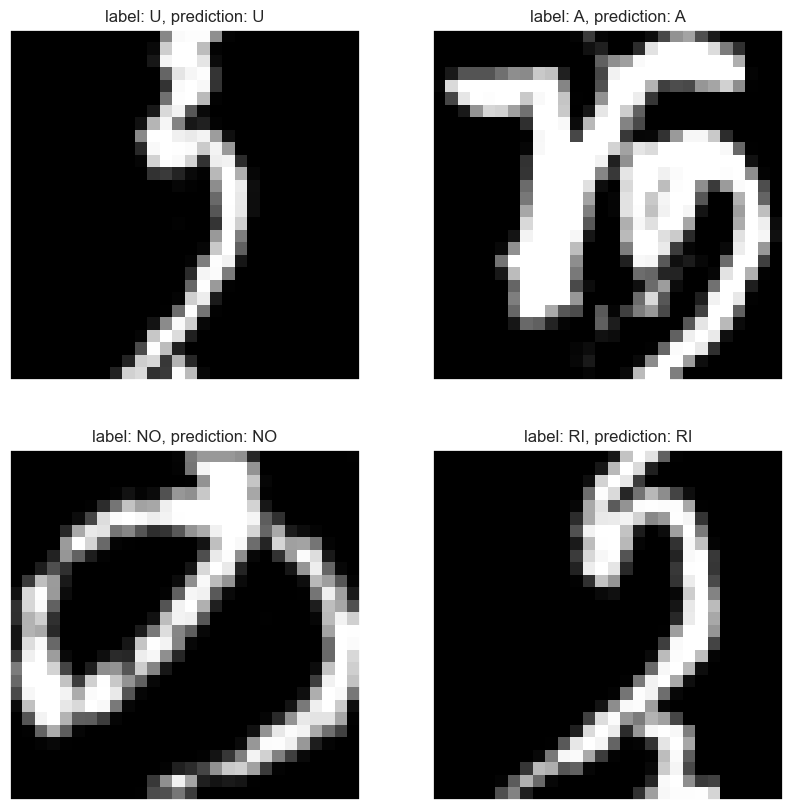

In [30]:
plot_grid_and_label(images, y_test, model_2, label_description=label_description, flatten_image=False)

In [32]:
# y_pred = ... # make predictions
y_pred = np.argmax(model_2.predict(images), axis=1)


1270/1270 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step


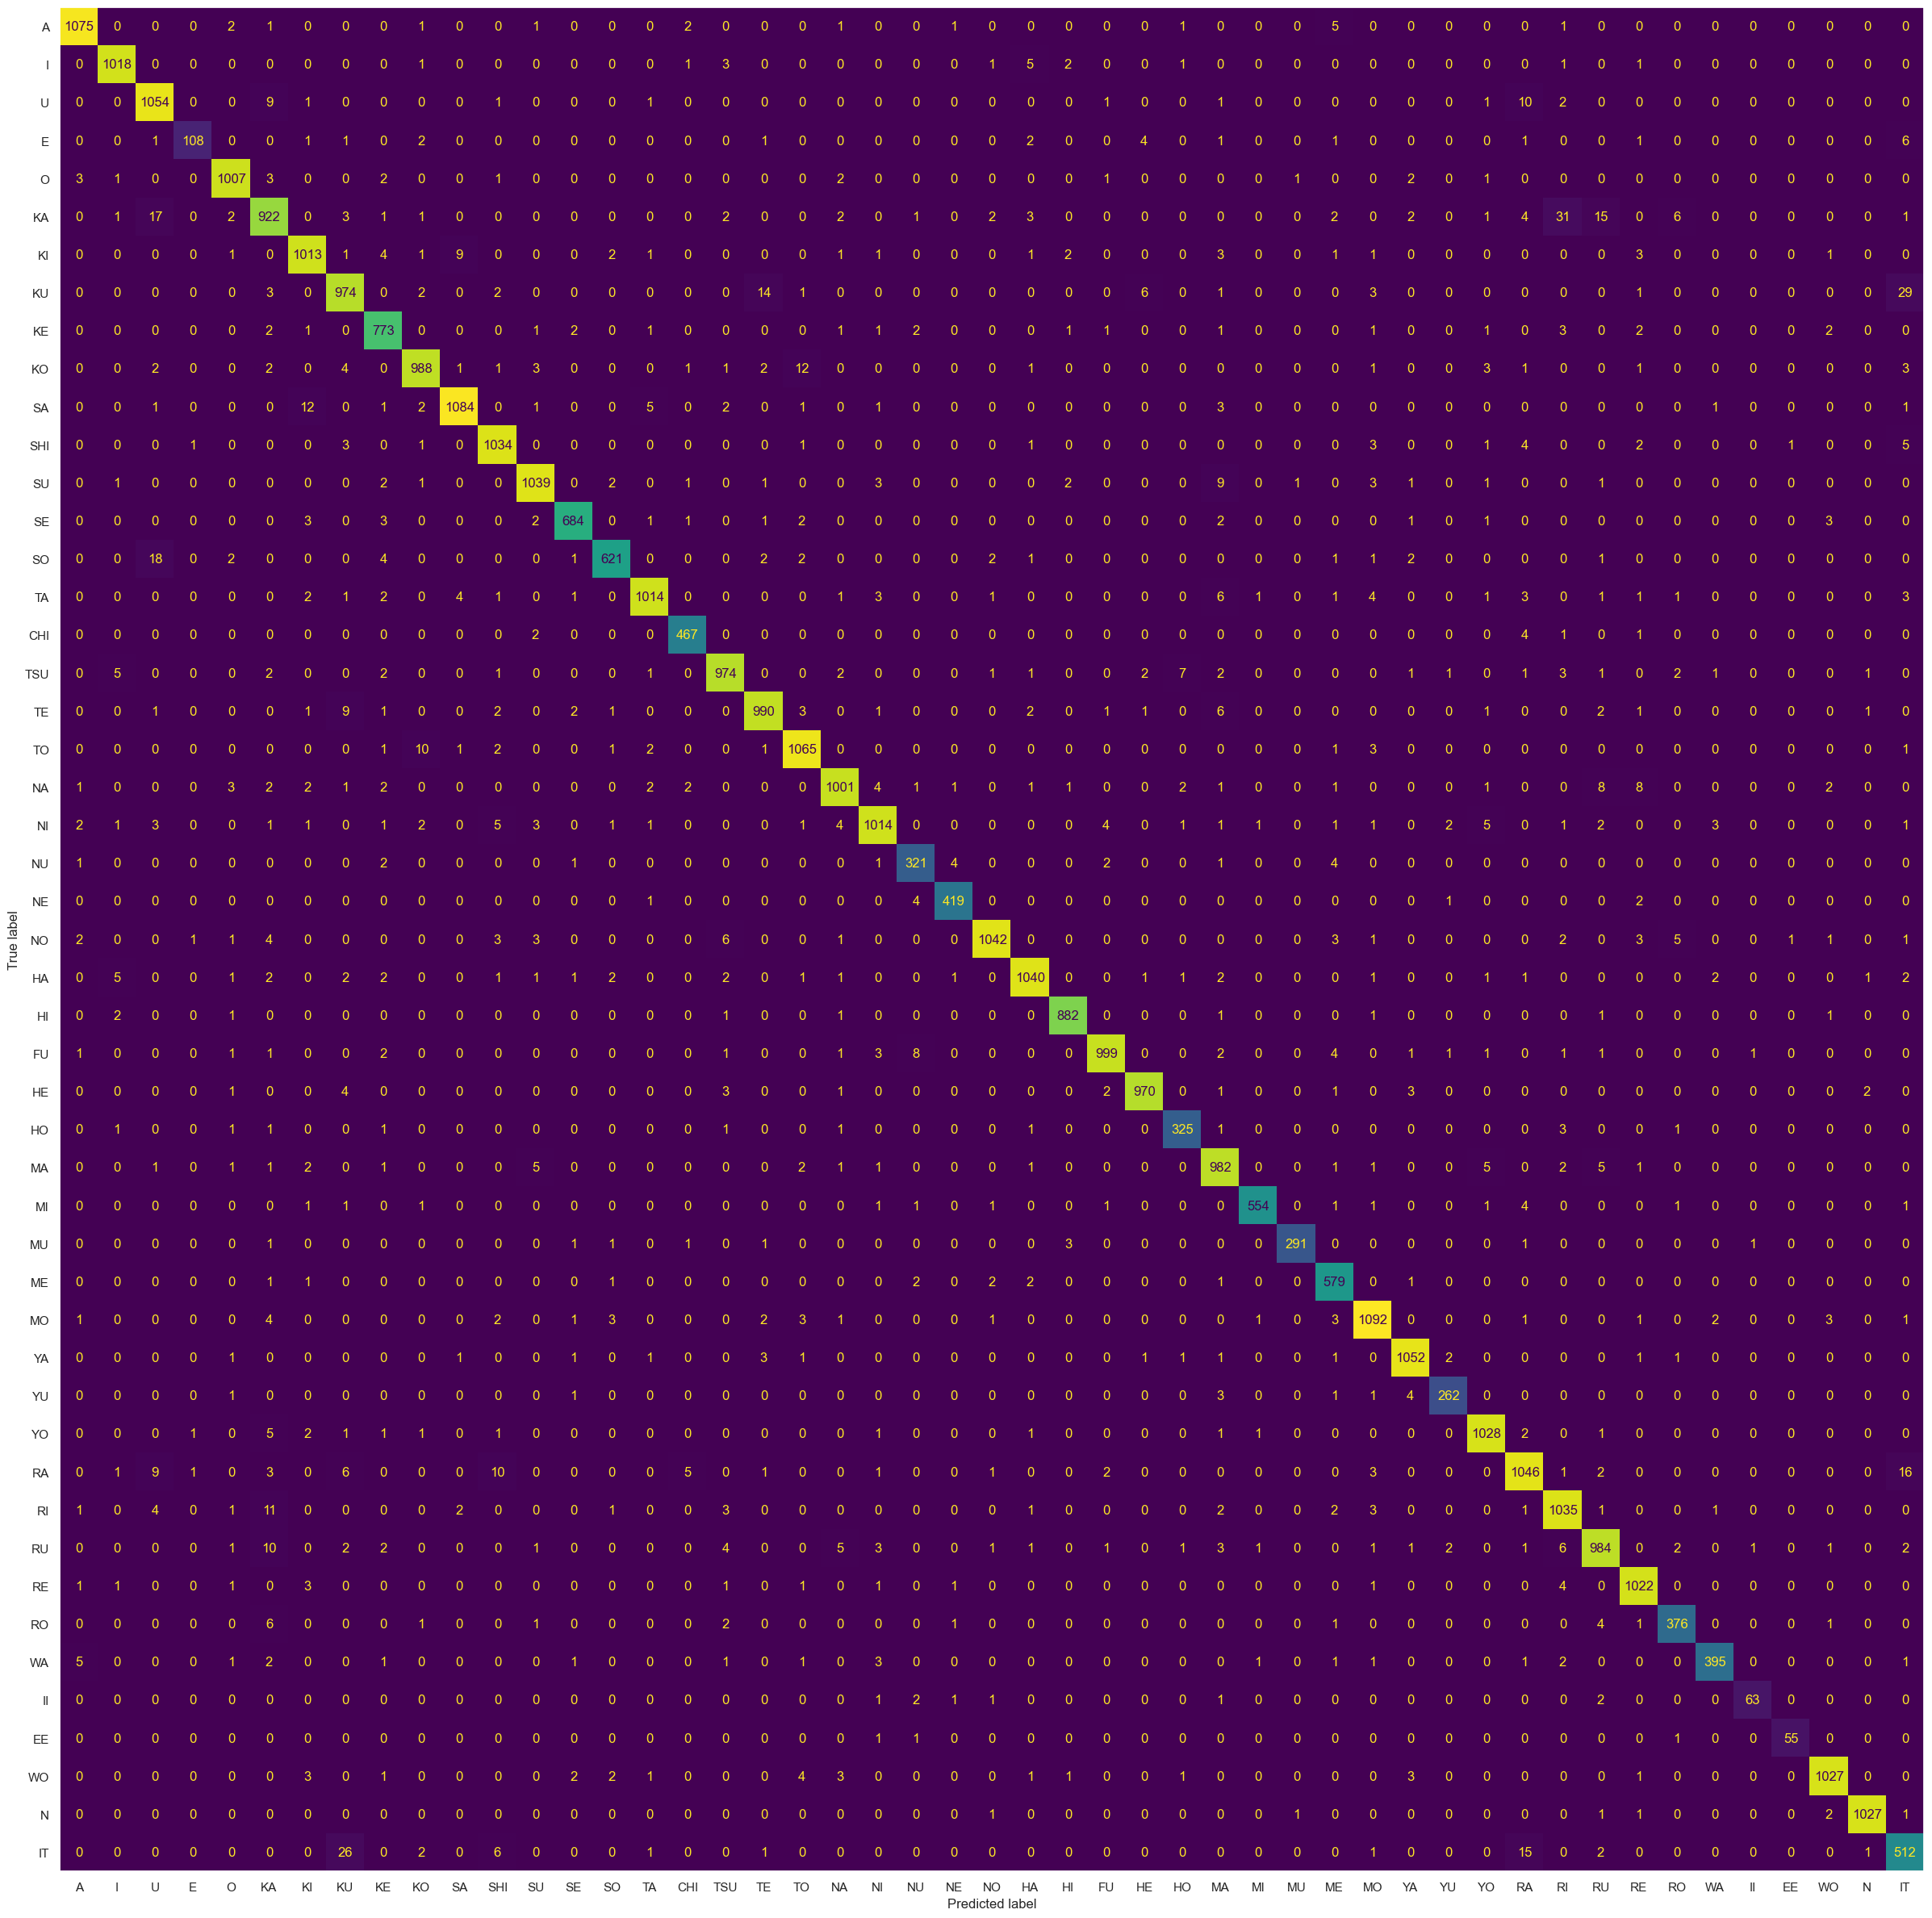

In [33]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [34]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.9618312034376639)